In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    RandomForestClassifier
)

from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
pd.read_csv("intern_performance.csv")

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,Finance,Male,27,Technician,2022-12-07 08:03:05.556036,1,Bachelor,4,4900.0,55,46,5,3,75,16,48,2,1.28,False
99996,99997,IT,Female,36,Consultant,2018-07-24 08:03:05.556036,6,Master,5,8250.0,39,35,7,0,0,10,77,1,3.48,True
99997,99998,Operations,Male,53,Analyst,2015-11-24 08:03:05.556036,8,High School,2,4800.0,31,13,6,5,0,5,87,1,2.60,False
99998,99999,HR,Female,22,Consultant,2015-08-03 08:03:05.556036,9,High School,5,8250.0,35,43,10,1,75,2,31,1,3.10,False


In [3]:
from google.colab import files

uploaded = files.upload()

Saving intern_performance.csv to intern_performance (1).csv


In [4]:
df = pd.read_csv("intern_performance.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (100000, 20)


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(100000, 20)

Column Names:
['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date', 'Years_At_Company', 'Education_Level', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Resigned']

Data Types:


,0
Employee_ID,int64
Department,object
Gender,object
Age,int64
Job_Title,object
Hire_Date,object
Years_At_Company,int64
Education_Level,object
Performance_Score,int64
Monthly_Salary,float64



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 n

In [6]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing Percentage": (missing.values / len(df)) * 100
})

display(missing_df)

,Column,Missing Values,Missing Percentage
0,Employee_ID,0,0.0
1,Department,0,0.0
2,Gender,0,0.0
3,Age,0,0.0
4,Job_Title,0,0.0
5,Hire_Date,0,0.0
6,Years_At_Company,0,0.0
7,Education_Level,0,0.0
8,Performance_Score,0,0.0
9,Monthly_Salary,0,0.0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
print("Performance Score Distribution:")
display(df["Performance_Score"].value_counts().sort_index())

Performance Score Distribution:


,count
Performance_Score,
1,20120
2,20013
3,19999
4,19940
5,19928


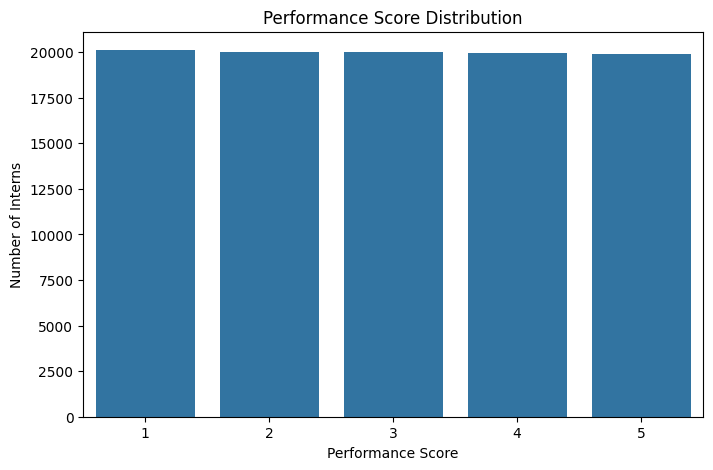

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Performance_Score"
)

plt.title("Performance Score Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Number of Interns")

plt.show()

In [10]:
categorical_columns = [
    "Department",
    "Gender",
    "Job_Title",
    "Education_Level"
]

for column in categorical_columns:
    print("\n" + "=" * 50)
    print(column)
    print("=" * 50)
    print(df[column].unique())


Department
['IT' 'Finance' 'Customer Support' 'Engineering' 'Marketing' 'HR'
 'Operations' 'Sales' 'Legal']

Gender
['Male' 'Female' 'Other']

Job_Title
['Specialist' 'Developer' 'Analyst' 'Manager' 'Technician' 'Engineer'
 'Consultant']

Education_Level
['High School' 'Bachelor' 'Master' 'PhD']


In [11]:
departments = sorted(df["Department"].dropna().unique().tolist())
job_titles = sorted(df["Job_Title"].dropna().unique().tolist())
genders = sorted(df["Gender"].dropna().unique().tolist())
education_levels = sorted(df["Education_Level"].dropna().unique().tolist())

print("Departments:")
print(departments)

print("\nJob Titles:")
print(job_titles)

print("\nGenders:")
print(genders)

print("\nEducation Levels:")
print(education_levels)

Departments:
['Customer Support', 'Engineering', 'Finance', 'HR', 'IT', 'Legal', 'Marketing', 'Operations', 'Sales']

Job Titles:
['Analyst', 'Consultant', 'Developer', 'Engineer', 'Manager', 'Specialist', 'Technician']

Genders:
['Female', 'Male', 'Other']

Education Levels:
['Bachelor', 'High School', 'Master', 'PhD']


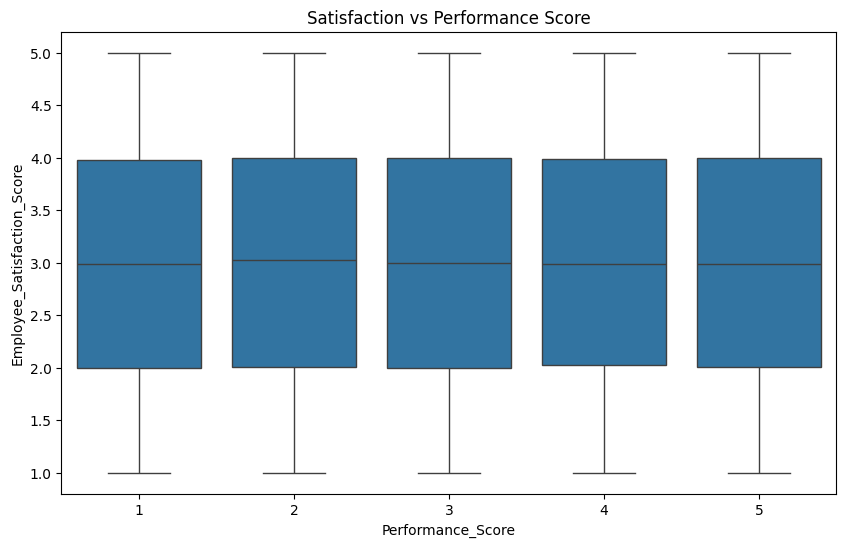

In [12]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Performance_Score",
    y="Employee_Satisfaction_Score"
)

plt.title("Satisfaction vs Performance Score")

plt.show()

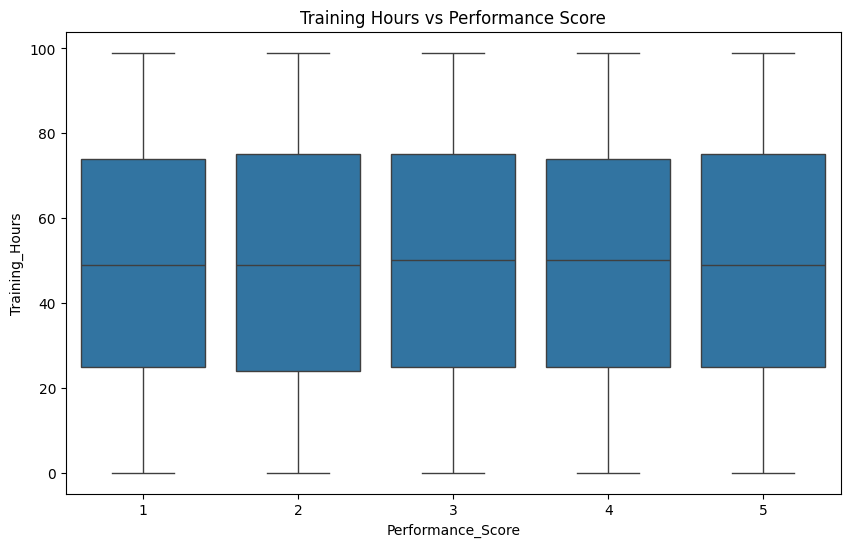

In [13]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Performance_Score",
    y="Training_Hours"
)

plt.title("Training Hours vs Performance Score")

plt.show()

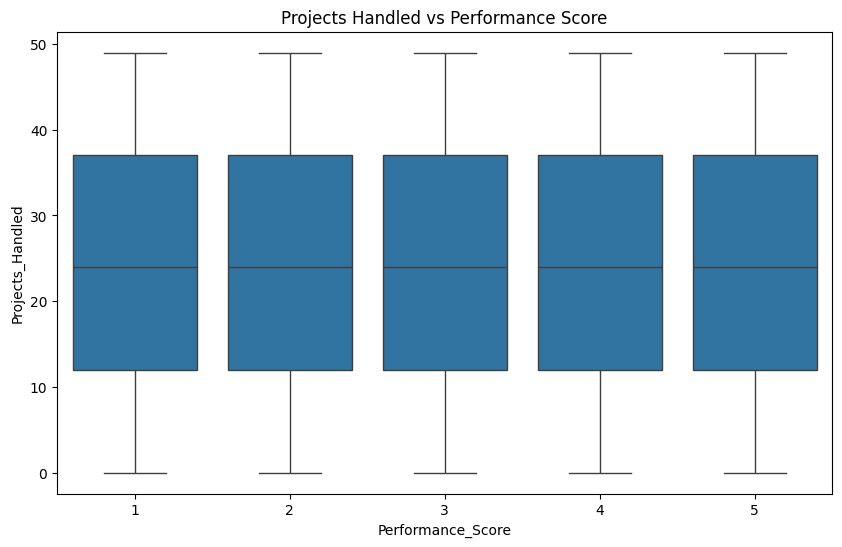

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Performance_Score",
    y="Projects_Handled"
)

plt.title("Projects Handled vs Performance Score")

plt.show()

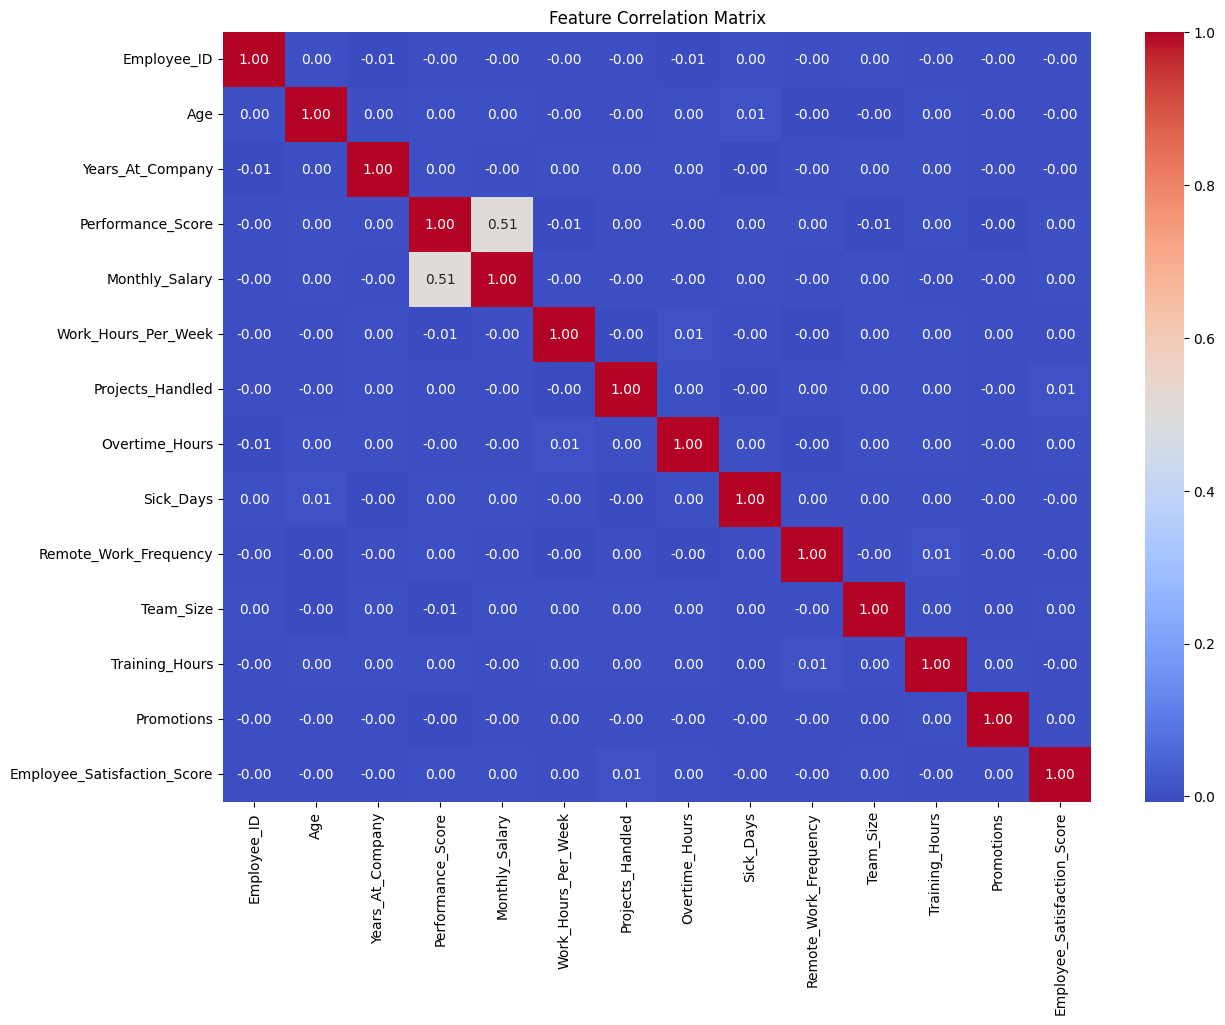

In [15]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

correlation = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [16]:
df["Hire_Date"] = pd.to_datetime(df["Hire_Date"])

df["Hire_Year"] = df["Hire_Date"].dt.year
df["Hire_Month"] = df["Hire_Date"].dt.month
df["Hire_Day"] = df["Hire_Date"].dt.day

df["Hire_DayOfWeek"] = df["Hire_Date"].dt.dayofweek

df.drop("Hire_Date", axis=1, inplace=True)

In [17]:
df = df.drop("Employee_ID", axis=1)

In [18]:
X = df.drop("Performance_Score", axis=1)

y = df["Performance_Score"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (100000, 21)
Target: (100000,)


In [19]:
categorical_features = [
    "Department",
    "Gender",
    "Job_Title",
    "Education_Level"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Department', 'Gender', 'Job_Title', 'Education_Level']

Numerical Features:
['Age', 'Years_At_Company', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Resigned', 'Hire_Year', 'Hire_Month', 'Hire_Day', 'Hire_DayOfWeek']


In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80000
Testing samples: 20000


In [22]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [23]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [25]:
y_pred = rf_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[2. 4. 3. 1. 4. 3. 5. 3. 4. 2.]


In [26]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MODEL PERFORMANCE
MAE  : 0.0000
MSE  : 0.0000
RMSE : 0.0000
R²   : 1.0000


In [27]:
models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Ridge Regression": Ridge(
        alpha=1.0
    )
}

In [28]:
results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "R2 Score",
        ascending=False
    )
)

,Model,MAE,RMSE,R2 Score
0,Random Forest,0.000000,0.000000,1.000000
1,Extra Trees,0.000000,0.000000,1.000000
2,Gradient Boosting,0.006705,0.008431,0.999965
3,Ridge Regression,0.188035,0.253720,0.967893


In [29]:
best_model_name = results_df.loc[
    results_df["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [30]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

final_model.fit(X_train, y_train)

print("Final model trained successfully.")

Final model trained successfully.


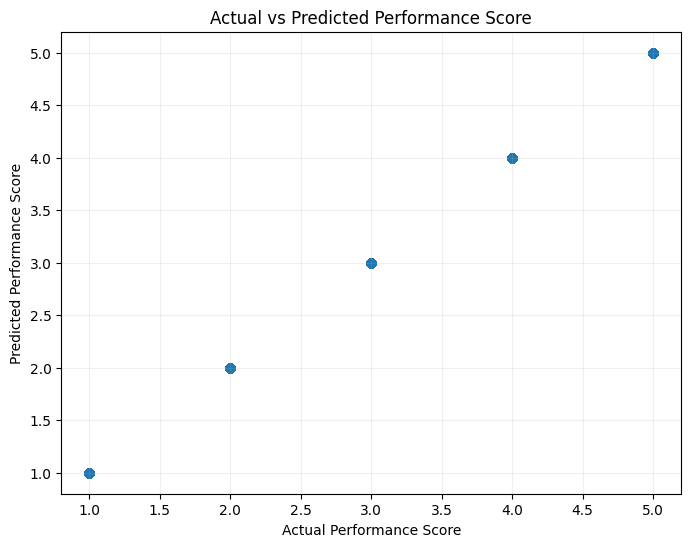

In [31]:
final_predictions = final_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.4
)

plt.xlabel("Actual Performance Score")
plt.ylabel("Predicted Performance Score")

plt.title(
    "Actual vs Predicted Performance Score"
)

plt.grid(alpha=0.2)

plt.show()

In [32]:
rounded_predictions = np.clip(
    np.rint(final_predictions),
    1,
    5
).astype(int)

actual_scores = y_test.astype(int)

accuracy = (
    rounded_predictions == actual_scores
).mean()

print(
    f"Exact Performance Score Accuracy: {accuracy * 100:.2f}%"
)

Exact Performance Score Accuracy: 100.00%


In [33]:
def performance_category(score):

    if score < 1.5:
        return "Poor"

    elif score < 2.5:
        return "Below Average"

    elif score < 3.5:
        return "Average"

    elif score < 4.5:
        return "Good"

    else:
        return "Excellent"

In [34]:
score = 4.3

print(
    performance_category(score)
)

Good


In [35]:
import ipywidgets as widgets

from IPython.display import display, clear_output

In [36]:
department_widget = widgets.Dropdown(
    options=departments,
    description="Department:",
    layout=widgets.Layout(width="450px")
)

gender_widget = widgets.Dropdown(
    options=genders,
    description="Gender:",
    layout=widgets.Layout(width="450px")
)

job_widget = widgets.Dropdown(
    options=job_titles,
    description="Job Title:",
    layout=widgets.Layout(width="450px")
)

education_widget = widgets.Dropdown(
    options=education_levels,
    description="Education:",
    layout=widgets.Layout(width="450px")
)

age_widget = widgets.IntSlider(
    value=int(df["Age"].median()),
    min=int(df["Age"].min()),
    max=int(df["Age"].max()),
    step=1,
    description="Age:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px")
)

years_widget = widgets.IntSlider(
    value=int(df["Years_At_Company"].median()),
    min=int(df["Years_At_Company"].min()),
    max=int(df["Years_At_Company"].max()),
    description="Years:",
    layout=widgets.Layout(width="450px")
)

In [37]:
salary_widget = widgets.FloatSlider(
    value=float(df["Monthly_Salary"].median()),
    min=float(df["Monthly_Salary"].min()),
    max=float(df["Monthly_Salary"].max()),
    step=50,
    description="Salary:",
    readout_format=".0f",
    layout=widgets.Layout(width="450px")
)

hours_widget = widgets.IntSlider(
    value=int(df["Work_Hours_Per_Week"].median()),
    min=int(df["Work_Hours_Per_Week"].min()),
    max=int(df["Work_Hours_Per_Week"].max()),
    description="Work Hours:",
    layout=widgets.Layout(width="450px")
)

projects_widget = widgets.IntSlider(
    value=int(df["Projects_Handled"].median()),
    min=int(df["Projects_Handled"].min()),
    max=int(df["Projects_Handled"].max()),
    description="Projects:",
    layout=widgets.Layout(width="450px")
)

overtime_widget = widgets.IntSlider(
    value=int(df["Overtime_Hours"].median()),
    min=int(df["Overtime_Hours"].min()),
    max=int(df["Overtime_Hours"].max()),
    description="Overtime:",
    layout=widgets.Layout(width="450px")
)

sick_widget = widgets.IntSlider(
    value=int(df["Sick_Days"].median()),
    min=int(df["Sick_Days"].min()),
    max=int(df["Sick_Days"].max()),
    description="Sick Days:",
    layout=widgets.Layout(width="450px")
)

remote_widget = widgets.IntSlider(
    value=int(df["Remote_Work_Frequency"].median()),
    min=int(df["Remote_Work_Frequency"].min()),
    max=int(df["Remote_Work_Frequency"].max()),
    step=25,
    description="Remote Work:",
    layout=widgets.Layout(width="450px")
)

In [38]:
team_widget = widgets.IntSlider(
    value=int(df["Team_Size"].median()),
    min=int(df["Team_Size"].min()),
    max=int(df["Team_Size"].max()),
    description="Team Size:",
    layout=widgets.Layout(width="450px")
)

training_widget = widgets.IntSlider(
    value=int(df["Training_Hours"].median()),
    min=int(df["Training_Hours"].min()),
    max=int(df["Training_Hours"].max()),
    description="Training Hours:",
    layout=widgets.Layout(width="450px")
)

promotion_widget = widgets.IntSlider(
    value=int(df["Promotions"].median()),
    min=int(df["Promotions"].min()),
    max=int(df["Promotions"].max()),
    description="Promotions:",
    layout=widgets.Layout(width="450px")
)

satisfaction_widget = widgets.FloatSlider(
    value=float(df["Employee_Satisfaction_Score"].median()),
    min=float(df["Employee_Satisfaction_Score"].min()),
    max=float(df["Employee_Satisfaction_Score"].max()),
    step=0.01,
    description="Satisfaction:",
    readout_format=".2f",
    layout=widgets.Layout(width="450px")
)

In [39]:
predict_button = widgets.Button(
    description="Predict Performance",
    button_style="success",
    icon="check",
    layout=widgets.Layout(
        width="250px",
        height="45px"
    )
)

output = widgets.Output()

In [40]:
def predict_performance(button):

    with output:

        clear_output()

        input_data = pd.DataFrame({

            "Department": [
                department_widget.value
            ],

            "Gender": [
                gender_widget.value
            ],

            "Age": [
                age_widget.value
            ],

            "Job_Title": [
                job_widget.value
            ],

            "Years_At_Company": [
                years_widget.value
            ],

            "Education_Level": [
                education_widget.value
            ],

            "Monthly_Salary": [
                salary_widget.value
            ],

            "Work_Hours_Per_Week": [
                hours_widget.value
            ],

            "Projects_Handled": [
                projects_widget.value
            ],

            "Overtime_Hours": [
                overtime_widget.value
            ],

            "Sick_Days": [
                sick_widget.value
            ],

            "Remote_Work_Frequency": [
                remote_widget.value
            ],

            "Team_Size": [
                team_widget.value
            ],

            "Training_Hours": [
                training_widget.value
            ],

            "Promotions": [
                promotion_widget.value
            ],

            "Employee_Satisfaction_Score": [
                satisfaction_widget.value
            ],

            "Resigned": [
                False
            ],

            "Hire_Year": [
                pd.Timestamp.now().year
            ],

            "Hire_Month": [
                pd.Timestamp.now().month
            ],

            "Hire_Day": [
                pd.Timestamp.now().day
            ],

            "Hire_DayOfWeek": [
                pd.Timestamp.now().dayofweek
            ]
        })

        prediction = final_model.predict(
            input_data
        )[0]

        prediction = np.clip(
            prediction,
            1,
            5
        )

        rounded_score = int(
            np.clip(
                np.rint(prediction),
                1,
                5
            )
        )

        category = performance_category(
            prediction
        )

        print("=" * 55)
        print("       INTERN PERFORMANCE PREDICTION")
        print("=" * 55)

        print(f"\nPredicted Score: {prediction:.2f} / 5")
        print(f"Performance Level: {category}")

        print("\nInput Profile")
        print("-" * 55)

        print(
            f"Department: {department_widget.value}"
        )

        print(
            f"Job Title: {job_widget.value}"
        )

        print(
            f"Education: {education_widget.value}"
        )

        print(
            f"Gender: {gender_widget.value}"
        )

        print("\nFinal Assessment")
        print("-" * 55)

        print(
            f"Expected Performance Rating: "
            f"{rounded_score}/5"
        )

In [41]:
predict_button.on_click(
    predict_performance
)

In [42]:
ui = widgets.VBox([

    widgets.HTML(
        "<h2>Intern Performance Prediction System</h2>"
    ),

    widgets.HTML(
        "<p>Select the intern's information below "
        "and click <b>Predict Performance</b>.</p>"
    ),

    department_widget,
    gender_widget,
    age_widget,
    job_widget,
    years_widget,
    education_widget,
    salary_widget,
    hours_widget,
    projects_widget,
    overtime_widget,
    sick_widget,
    remote_widget,
    team_widget,
    training_widget,
    promotion_widget,
    satisfaction_widget,

    widgets.HTML("<br>"),

    predict_button,

    output
])

display(ui)

       INTERN PERFORMANCE PREDICTION

Predicted Score: 2.00 / 5
Performance Level: Below Average

Input Profile
-------------------------------------------------------
Department: Finance
Job Title: Consultant
Education: PhD
Gender: Male

Final Assessment
-------------------------------------------------------
Expected Performance Rating: 2/5
       INTERN PERFORMANCE PREDICTION

Predicted Score: 2.00 / 5
Performance Level: Below Average

Input Profile
-------------------------------------------------------
Department: Finance
Job Title: Consultant
Education: PhD
Gender: Male

Final Assessment
-------------------------------------------------------
Expected Performance Rating: 2/5
